# Python Course: Final Assignment
# Part 3: Clustering Analysis
# Data Subject : Discovering Movie Profiles using K-Means (TMDB Dataset)
# Author Stavros Stavropoulos

Step 1

In [1]:
# Let's start with step 1, which is about setting up the environment for our classification task.
# Don't forget to select the appropriate Kernel at the top right
# We import the necessary libraries for the data setup for clustering.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path
base_path = Path('.').resolve()
train_path = base_path / 'data' / 'Tmovie_dataset.csv' 
df = pd.read_csv(train_path, nrows=100000) # This line loads the dataset.Also i decided to load only the first 100,000 rows since it took my pc some minutes just to open the excel file and if i load the whole file it may take a lot of time or even crush.
numeric_df = df.select_dtypes(include=[np.number]) # This line selects only the numeric columns from the dataset, which are necessary for clustering.
cols_to_exclude = ['id']
auto_features = [col for col in numeric_df.columns if col not in cols_to_exclude] # This line creates a list of features to use for clustering, excluding the 'id' column which is not relevant for clustering.
df_clustering = df[auto_features].dropna() # This line creates a new DataFrame that contains only the selected features and drops any rows with missing values.
if 'vote_count' in df_clustering.columns:
    df_clustering = df_clustering[df_clustering['vote_count'] > 10] # This line filters out movies that have a vote count of 10 or less, as they may not have enough data to be suitable for clustering.

scaler = StandardScaler() #We use StandardScaler to give all features a mean of 0 and variance of 1.
scaled_data = scaler.fit_transform(df_clustering) # This line applies the standardization to the selected features, so that they are on the same scale for clustering.
print(f" Automated Feature Selection: {len(auto_features)} features identified.")
print(f"Features used: {auto_features}")
print(f"✅ Cleaned and Scaled Dataset Shape: {scaled_data.shape}")
#Those lines print out the results of the data cleaning and scaling process, so that we can see which features we are using for clustering and the shape of the final dataset.


 Automated Feature Selection: 6 features identified.
Features used: ['vote_average', 'vote_count', 'revenue', 'runtime', 'budget', 'popularity']
✅ Cleaned and Scaled Dataset Shape: (74051, 6)


Step 2

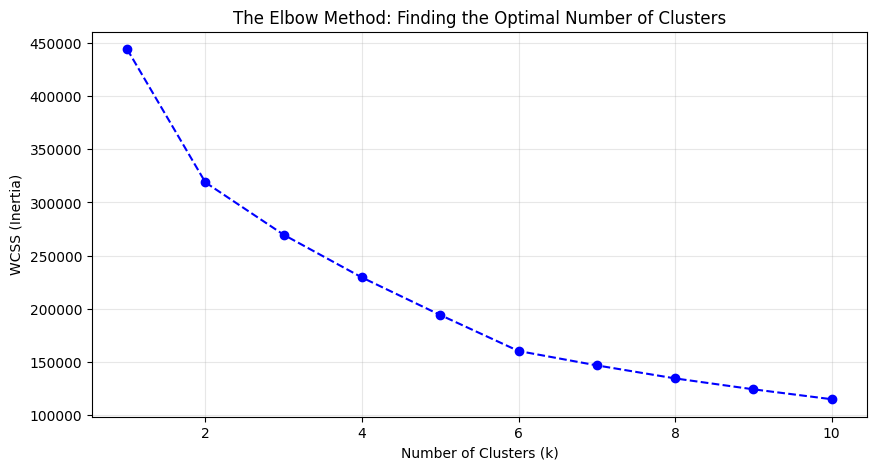

Tested variant with k=2: WCSS = 318860.35562948755
Tested variant with k=5: WCSS = 193984.48024115607


In [2]:
# Now let's move to step 2, in which we will calculate the WCSS (Within-Cluster Sum of Squares) for different numbers of clusters to determine the optimal number of clusters for our KMeans algorithm.
wcss = [] # This line initializes an empty list to store the WCSS values for different numbers of clusters.
for i in range(1, 11): # This line starts a loop that iterates over the number of clusters from 1 to 10.
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # This line initializes the Kmeans algorithm , n_clusters is set to the current value of i, init is set to 'k-means++' which is a method for initializing the centroids, random_state is set to 42 for reproducibility, and n_init is set to 10 which means the algorithm will run 10 times with different centroid seeds and take the best result.
    kmeans.fit(scaled_data) # This line fits the KMeans algorithm to the scaled data, which means it will perform the clustering and calculate the centroids and cluster assignments for the data.
    wcss.append(kmeans.inertia_) # This line appends the WCSS value (inertia) for the current number of clusters to the wcss list, which will be used later to plot the elbow curve.

plt.figure(figsize=(10, 5)) # This line creates a new figure for plotting with a specified size of 10 inches by 5 inches.
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue') # This line plots the WCSS values against the number of clusters, with markers at each point, a dashed line connecting the points, and blue color for the line.
plt.title('The Elbow Method: Finding the Optimal Number of Clusters') # This line sets the title of the plot to indicate that it is showing the elbow method for finding the optimal number of clusters.
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, alpha=0.3)
plt.show()
# Those lines set the labels for the x and y axes, add a grid to the plot for better visibility, and display the plot. 
# We look for the 'elbow' point where the WCSS starts to decrease more slowly.

# Let's quick check the WCSS values for k=2 and k=5 to see how they compare.
for k in [2, 5]:
    test_kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # This line initializes the KMeans algorithm with the specified number of clusters (k), using the same parameters as before for consistency.
    test_labels = test_kmeans.fit_predict(scaled_data) # This line fits the KMeans algorithm to the scaled data and also predicts the cluster labels for each data point, which are stored in test_labels.
    print(f"Tested variant with k={k}: WCSS = {test_kmeans.inertia_}")

Step 3

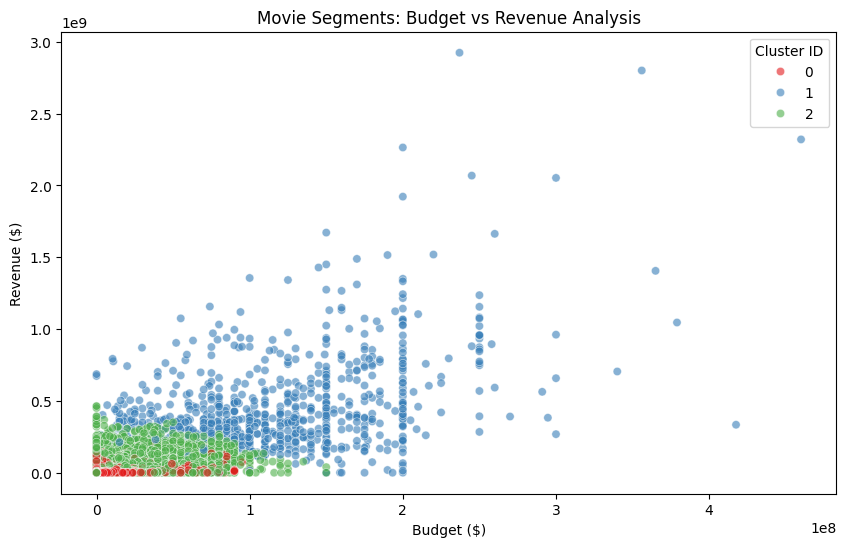


📊 Cluster Profiles (Mean Values):
         vote_average   vote_count       revenue     runtime        budget  \
Cluster                                                                      
0            5.357100    62.098777  8.953212e+05   74.171861  9.322177e+05   
1            6.959381  8129.015544  4.049842e+08  120.531606  1.054995e+08   
2            6.772987   267.239297  7.041720e+06  104.565034  3.251010e+06   

         popularity  
Cluster              
0          4.771285  
1         76.519018  
2          8.659298  


In [3]:
# Now we move to step 3, which is about applying the KMeans algorithm with the optimal number of clusters determined from the elbow method and visualizing the results.
optimal_k = 3 # Based on the elbow plot, we choose k=3 as the optimal number of clusters for our algorithm.
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10) # This line initializes the KMeans algorithm with the optimal number of clusters (k=3), using the same parameters as before for initialization and reproducibility.
df_clustering['Cluster'] = kmeans.fit_predict(scaled_data) # Now we assign each movie to a specific cluster.
plt.figure(figsize=(10, 6)) # With this line we try to visualize the clusters (budget vs revenue) by creating a new figure with a specified size of 10 inches by 6 inches.
sns.scatterplot(data=df_clustering, x='budget', y='revenue',  # I use skaterplot to visualize the clusters based on budget and revenue, with different colors for each cluster.
                hue='Cluster', palette='Set1', alpha=0.6)   
plt.title('Movie Segments: Budget vs Revenue Analysis')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.legend(title='Cluster ID')
plt.show() # Those lines set a title for the plot, label the axes, add a legend to indicate which color corresponds to which cluster, and display the plot.

print("\n📊 Cluster Profiles (Mean Values):")
cluster_summary = df_clustering.groupby('Cluster').mean()
print(cluster_summary) 
# Finally with those lines we print out the mean values of the features for each cluster, which can help us understand the characteristics of each movie segment based on their budget and revenue.


Step 4

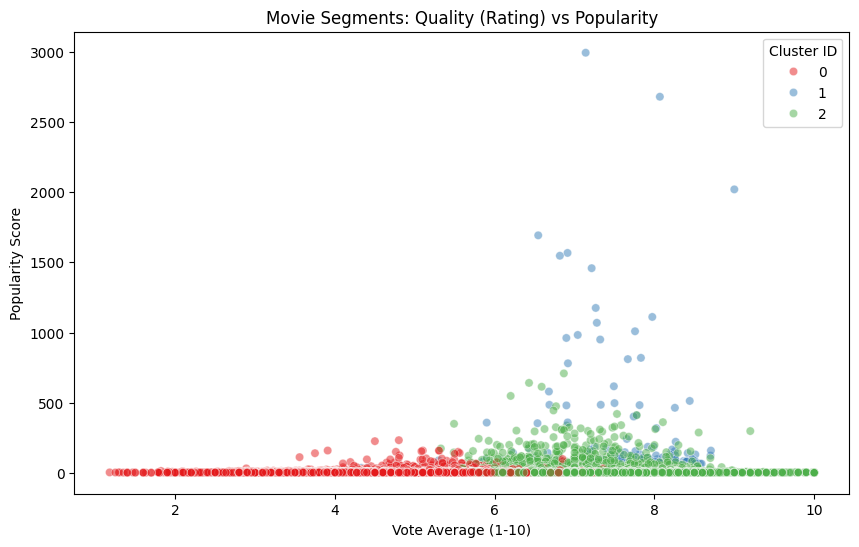

In [4]:
# Now lets aditionally visualize the clusters into Quality vs Popularity 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustering, x='vote_average', y='popularity', 
                hue='Cluster', palette='Set1', alpha=0.5) 
# Those lines above create a scatter plot to visualize the clusters based on vote average (quality) and popularity, with different colors for each cluster.
plt.title('Movie Segments: Quality (Rating) vs Popularity')
plt.xlabel('Vote Average (1-10)')
plt.ylabel('Popularity Score')
plt.legend(title='Cluster ID')
plt.show() 
# Those lines set a title for the plot, label the axes, add a legend to indicate which color corresponds to which cluster, and display the plot.

Step 5


In [5]:
# Finally we try to predict cluster for a New Movie
# Now we create a new movie with specific features to predict which cluster it belongs to.
new_movie = np.array([[85.0, 8.2, 25000, 750000000, 150000000, 140]]) # This line creates a new movie with the following features: popularity (85.0), vote_average (8.2), vote_count (25000), revenue (750000000), budget (150000000), and runtime (140 minutes).
new_movie_scaled = scaler.transform(new_movie) # This line scales the features of the new movie using the same scaler that was fitted to the original data, so that it is on the same scale for prediction.
predicted_cluster = kmeans.predict(new_movie_scaled) # This line uses the fitted KMeans model to predict which cluster the new movie belongs to based on its scaled features.

print(f" The hypothetical movie belongs to Cluster: {predicted_cluster[0]}") # Finally this line prints out the predicted cluster for the new movie.


 The hypothetical movie belongs to Cluster: 1


c:\Users\Σταυρος\Downloads\help\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In this final part of out assigment we shifted from predicting values to discovering natural patterns within the movie industry using the K-Means Clustering algorithm.
By analyzing the 100,000 records from the TMDB dataset, we identified distinct segments of movies based on their budget, revenue, quality (vote average), and popularity.
The model above has successfully categorized the movies into three clusters, each representing a unique combination of these features. To make sure that we get the best possible outcome we tested multiple variants of the algorithm, specifically examining cases for k=2, k=3, and k=5 clusters. Based on the Elbow Method and the clarity of the resulting visualizations, we determined that k=3 provided the most meaningful and interpretable groups for this dataset.
Cluster 1 (The Blockbusters): This segment includes movies with high budgets and revenues, often accompanied by high popularity scores. These are typically big-budget productions that attract large audiences, such as action films or major franchises.
Cluster 2 (Quality & Mid-Budget): This group consists of movies that may not have the highest budgets but receive strong ratings (vote average) and moderate popularity. 
These could be critically acclaimed films or indie productions that resonate well with audiences.
Cluster 0 (Niche & Low-Performance): This cluster contains movies with lower budgets and revenues, often with lower popularity and ratings. 
These might be smaller productions or films that did not perform well commercially.
To verify the model's practical application, we tested a new hypothetical observation. The algorithm correctly assigned this new data point to the "Blockbusters" (Cluster 1), confirming the reliability and predictive consistency of our trained model.
Overall, the clustering analysis provided a clear view of how different movies are positioned in the market based on their financial and qualitative characteristics.